# **🛩️ ATAS**

The **ATAS** (Airial Threat Assesment System) is an end-to-end machine learning engineering project that combines
- computer vision,
- structured machine learning,
- tactical scenario generation,
- and interactive visualization into a single pipeline.

**The project is divided into three major components:**
- Aircraft Classification Model
- ETA Regressor Model
- Hit Classification Model
---

#### **In this notebook**

# **Aircraft Classification Model**

This notebook focuses on building the **Aircraft Classification Model** using `TensorFlow` and `transfer learning techniques` to classify military aircraft into  `101` different categories.

## **1. Problem Definition**

Given an image of a military aircraft, can a deep learning computer vision model (multi-class classification neural network) correctly classify the aircraft into its respective category?

---

## **2. Dataset**

The dataset used in this project contains military aircraft images across 101 aircraft categories and is being taken from [Military Aircraft Detection Dataset on Kaggle](https://www.kaggle.com/datasets/a2015003713/militaryaircraftdetectiondataset/data).

The dataset includes:
- fighter jets,
- bombers,
- helicopters,
- transport aircraft,
- UAVs,
- and reconnaissance aircraft.

Images contain variations in:
- aircraft angles,
- lighting conditions,
- backgrounds,
- scales,
- and image quality.

For this notebook, the `crop/` portion of the dataset will be used since it already contains aircraft images organized by class labels, making it suitable for multi-class image classification tasks.

The dataset was originally designed for fine-grained military aircraft recognition, where some visually similar aircraft variants are grouped into the same class due to minimal external differences.

<details>
<summary>View all 101 aircraft classes</summary>

`A10, A400M, AG600, AH64, AKINCI, AV8B, An124, An22, An225, An72, B1, B2, B21, B52, Be200, C1, C130, C17, C2, C390, C5, CH47, CH53, CL415, E2, E7, EF2000, EMB314, F117, F14, F15, F16, F18, F2, F22, F35, F4, FCK1, H6, Il76, J10, J20, J35, J36, J50, JAS39, JF17, JH7, KAAN, KC135, KF21, KIZILELMA, KJ600, Ka27, Ka52, MQ20, MQ25, MQ28, MQ9, Mi24, Mi26, Mi28, Mi8, Mig29, Mig31, Mirage2000, NH90, P3, RQ4, Rafale, SR71, Su24, Su25, Su34, Su47, Su57, T50, TB001, TB2, Tejas, Tornado, Tu160, Tu22M, Tu95, U2, UH60, US2, V22, V280, Vulcan, WZ10, WZ7, WZ9, X29, X32, XB70, XQ58, Y20, YF23, Z10, Z19`

</details>

---

## **3. Evaluation**

The goal is to correctly classify a military aircraft image into one of 101 categories.

The model will be considered performing well if it achieves **above 80% classification accuracy** on the validation set.

Additional indicators we will track:
- training & validation loss curves (to detect overfitting),
- confusion matrix (to see which aircraft classes the model confuses with each other),
- per-class prediction confidence,
- and visual inspection of sample predictions.

---

## **4. Features**

Some information about the data:

* We are dealing with images (unstructured data) so we will be using deep learning / transfer learning.
* There are `101` categories of military aircraft (101 different classes).
* The `crop/` folder contains `41,441` total cropped aircraft images organized by class label.
* Each class has its own subfolder inside `crop/` — the folder name is the label.
* The `labels_with_split.csv` file contains bounding box annotations and a predefined split column:
  - ~31k training annotations
  - ~7.5k validation annotations
  - ~2.7k test annotations

* Note: This CSV was designed for object detection. For our classifier we use the `crop/` folder directly, but will use the `split` column to respect the original train/validation/test separation.
* Images vary in angle, lighting, background, and scale — making this a fine-grained classification problem.
* Some visually similar aircraft variants are grouped into the same class due to minimal external differences.

## **5. Preparing the Tools**

We will be using the following libraries for this project:
- **NumPy** — numerical operations
- **Pandas** — data manipulation and loading labels
- **Matplotlib** — visualizing images and training curves
- **TensorFlow / Keras** — building and training the deep learning model
- **Scikit-learn** — creating train/validation/test splits and evaluation metrics
- **OS / Pathlib** — navigating file paths and loading images from disk

In [2]:
# Importing the required tools

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)
print("Keras Version:", keras.__version__)

# Able to see all the columns
pd.set_option('display.max_columns', None)

2026-05-11 12:37:29.471155: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-11 12:37:41.275837: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TensorFlow Version: 2.16.1
NumPy Version: 1.26.4
Pandas Version: 3.0.2
Keras Version: 3.14.0


## **6. Load Images**

We will load images from the `crop/` folder of the dataset.
Each subfolder inside `crop/` represents one aircraft class and contains cropped images of that aircraft.

Steps:
1. Define the path to the `crop/` folder ✅
2. Count total images and classes ✅
3. Load image file paths and their corresponding class labels ✅
4. Verify the data loaded correctly ✅

### **Environment & Path Configuration**

This section configures project paths and automatically detects whether the notebook is running **locally** or in **Google Colab**.

In [80]:
import glob
from pathlib import Path
import os

# Set to "auto" (recommended), "colab", or "local"
FORCE_ENV = "auto"

def detect_env():
    in_colab = "COLAB_GPU" in os.environ or os.path.exists("/content")
    return "colab" if in_colab else "local"

ENV = detect_env() if FORCE_ENV == "auto" else FORCE_ENV

if ENV == "colab":
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/ATAS_Project")
    DATA_ROOT = PROJECT_ROOT / "data"
    LOG_DIR = PROJECT_ROOT / "logs"
    MODEL_DIR = PROJECT_ROOT / "models"
else:
    PROJECT_ROOT = Path("..")
    DATA_ROOT = PROJECT_ROOT / "data"
    LOG_DIR = PROJECT_ROOT / "logs"
    MODEL_DIR = PROJECT_ROOT / "models"

CROP_DIR = DATA_ROOT / "crop"

print("ENV:", ENV)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("CROP_DIR:", CROP_DIR)
print("LOG_DIR:", LOG_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("CROP_DIR exists:", CROP_DIR.exists())
print("Classes found:", len(glob.glob(str(CROP_DIR / "*"))))

ENV: local
PROJECT_ROOT: ..
DATA_ROOT: ../data
CROP_DIR: ../data/crop
LOG_DIR: ../logs
MODEL_DIR: ../models
CROP_DIR exists: True
Classes found: 101


In [4]:
import os
from pathlib import Path

CROP_DIR = DATA_ROOT / "crop"

class_folders = sorted(os.listdir(CROP_DIR))
total_images = sum(len(os.listdir(CROP_DIR / cls)) for cls in class_folders)

print(f"Total classes: {len(class_folders)}")
print(f"Total images: {total_images}")

Total classes: 101
Total images: 41441


In [5]:
# Checking out labels csv

labels_with_split = pd.read_csv("../data/labels_with_split.csv")
print(labels_with_split.shape)
print(labels_with_split.head())

(41441, 9)
                           filename  width  height class  xmin  ymin  xmax  \
0  0000e97ea2d086d6759b19b288a8a72c   4928    3264  Mi28  1380  1904  1522   
1  0000e97ea2d086d6759b19b288a8a72c   4928    3264  Mi28  1809  1625  1958   
2  0000e97ea2d086d6759b19b288a8a72c   4928    3264  Mi28  2400  1571  2532   
3  0000e97ea2d086d6759b19b288a8a72c   4928    3264  Mi28  3935  1772  4100   
4  00010041af654d0b8e1e16c824fa9867   1360    2048  UH60   835   526  1233   

   ymax  split  
0  2014  train  
1  1759  train  
2  1727  train  
3  1891  train  
4   741  train  


In [6]:
labels_with_split

,filename,width,height,class,xmin,ymin,xmax,ymax,split
0,0000e97ea2d086d6759b19b288a8a72c,4928,3264,Mi28,1380,1904,1522,2014,train
1,0000e97ea2d086d6759b19b288a8a72c,4928,3264,Mi28,1809,1625,1958,1759,train
2,0000e97ea2d086d6759b19b288a8a72c,4928,3264,Mi28,2400,1571,2532,1727,train
3,0000e97ea2d086d6759b19b288a8a72c,4928,3264,Mi28,3935,1772,4100,1891,train
4,00010041af654d0b8e1e16c824fa9867,1360,2048,UH60,835,526,1233,741,train
...,...,...,...,...,...,...,...,...,...
41436,fff4d4af52e64d95bdafa29f77a81c97,817,479,Mi28,0,119,756,301,test
41437,fffb908c9824dc0da884c43cfe0312b8,6720,4480,EF2000,514,1302,6447,3206,test
41438,fffb908c9824dc0da884c43cfe0312b8,6720,4480,EF2000,0,1746,2698,3061,test
41439,fffd70f851b78035454c0a9367820ca3,1500,1000,B2,240,55,988,944,test


In [7]:
labels_with_split.describe()

,width,height,xmin,ymin,xmax,ymax
count,41441.000000,41441.000000,41441.000000,41441.000000,41441.000000,41441.000000
mean,2056.475133,1399.343307,715.019087,507.202191,1325.372144,805.921817
std,1276.872710,830.675656,798.662180,465.634793,953.931200,573.969376
min,112.000000,119.000000,0.000000,0.000000,22.000000,9.000000
25%,1080.000000,768.000000,142.000000,185.000000,668.000000,411.000000
50%,1600.000000,1170.000000,449.000000,366.000000,1041.000000,639.000000
75%,2830.000000,1879.000000,981.000000,685.000000,1712.000000,1034.000000
max,8508.000000,7360.000000,7895.000000,4919.000000,8256.000000,6720.000000


In [8]:
# Checking wheather there any null values
labels_with_split.info()

<class 'pandas.DataFrame'>
RangeIndex: 41441 entries, 0 to 41440
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  41441 non-null  str  
 1   width     41441 non-null  int64
 2   height    41441 non-null  int64
 3   class     41441 non-null  str  
 4   xmin      41441 non-null  int64
 5   ymin      41441 non-null  int64
 6   xmax      41441 non-null  int64
 7   ymax      41441 non-null  int64
 8   split     41441 non-null  str  
dtypes: int64(6), str(3)
memory usage: 2.8 MB


**From info given above:**
- `filename`, `class`, `split` --> are of `str` datatype
- `width`, `height`, `xmin`, `ymin`, `xmax`, `ymax` --> are of `int` data types 

In [9]:
# Counting number of classes in the labels file
labels_with_split["class"].value_counts()

class
F16     2061
F18     1796
C130    1590
F35     1569
F15     1564
        ... 
J50       46
V280      39
WZ10      32
WZ9       15
MQ20      11
Name: count, Length: 101, dtype: int64

**Class distribution is very unbalanced:**

Example:
- **F16** has `2,061` crops
- **MQ20** has only `11`

That's a big gap. Some aircraft are rare in the dataset, some are very common. This will matter later when we train, but we'll handle it when we get there.

In [10]:
# Checking the split division of the dataset
labels_with_split["split"].value_counts()

split
train         31127
validation     7545
test           2769
Name: count, dtype: int64

**We use the CSV to build full file paths for each image.
Each row will have: filepath, label, and split.**

In [11]:
# Peek inside one class folder to see how filenames are structred

sample_class = os.listdir(CROP_DIR)[0]
print("Class: ", sample_class)

sample_files = os.listdir(CROP_DIR/ sample_class)[:5]
print("Files: ", sample_files)

Class:  A10
Files:  ['00c09f406d31a0cd9402862fbd26d930_0.jpg', '00d4b7ea93ca1417393007c61c519f88_0.jpg', '01169f9ba735dfcb46dab62bc5649de9_0.jpg', '016fd73cdece1b76562ec526ba9390ff_0.jpg', '01ed4d81c5d733cbaa266b6ea7821254_0.jpg']


**It confirmed two things:**

- The class folder name **(A10)** is the label
- The files inside are the cropped images we'll use

That's it. That's all we needed to see.

---

### **Building the File Path Dataframe**
Scan all class folders in `crop/` and build a clean dataframe with filepath and label columns.

**We write code that does this:**

- Go through every class folder in crop/
- For every image inside, record the full path and the folder name as the label
- End up with a clean dataframe of filepath + label

In [12]:
# Data Collection
# Scan all the folders and build filepath + label list

records = []

for class_folder in CROP_DIR.iterdir():
    if class_folder.is_dir():
        for image_path in class_folder.glob("*.jpg"):
            records.append({
                "filepath" : str(image_path),
                "label" : class_folder.name
            })            
# records

In [13]:
# Convert to a dataframe
image_df = pd.DataFrame(records)
print(image_df.shape)
print(image_df.head())

(41441, 2)
                                            filepath label
0  ../data/crop/A10/00c09f406d31a0cd9402862fbd26d...   A10
1  ../data/crop/A10/00d4b7ea93ca1417393007c61c519...   A10
2  ../data/crop/A10/01169f9ba735dfcb46dab62bc5649...   A10
3  ../data/crop/A10/016fd73cdece1b76562ec526ba939...   A10
4  ../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...   A10


In [14]:
image_df.head()

,filepath,label
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10


In [15]:
labels_with_split.shape, image_df.shape

# Both having same number of rows

((41441, 9), (41441, 2))

#### **Merging: Add Split Information**

#### **What We Have So Far**

Our `image_df` dataframe:
- **41,441 rows** ✅ (matches the CSV exactly)
- **2 columns:** `filepath`, `label`
- Labels extracted from folder names ✅

#### **What We Need**

Add the `split` column from `label_with_split.csv` so we know which images are for:
- **Training** (75%)
- **Validation** (18%)
- **Testing** (7%)

#### **The Challenge: Joining Two Tables**

Both dataframes have the same 41,441 images, but they identify them differently:

| Source | File ID Format | Example |
|--------|----------------|---------|
| `image_df` | Full filepath | `../data/crop/A10/00c09f406d31a0cd9_0.jpg` |
| `label_with_split` | Filename only | `00c09f406d31a0cd9` |

**We need to extract the filename from the filepath and use it as the merge key.**

In [16]:
# Get first filename from CSV for Mi28
mi28_csv = labels_with_split[labels_with_split["class"] == "Mi28"]["filename"].iloc[0]
print("CSV filename for Mi28: ", mi28_csv)

# Get the first file from Mi28 crop folder
mi28_crop = os.listdir(CROP_DIR/ "Mi28")[:5]
print("Crop filename: ", mi28_crop)

CSV filename for Mi28:  0000e97ea2d086d6759b19b288a8a72c
Crop filename:  ['0000e97ea2d086d6759b19b288a8a72c_0.jpg', '0000e97ea2d086d6759b19b288a8a72c_1.jpg', '0000e97ea2d086d6759b19b288a8a72c_2.jpg', '0000e97ea2d086d6759b19b288a8a72c_3.jpg', '04dbc4ca7d87fb38b22b415bc7c280c0_0.jpg']


### **Adding Split Column to image_df**

We need to match each image filepath to its train/val/test split from the CSV.

The crop filenames look like: `0000e97e_0.jpg`  
The CSV filenames look like: `0000e97e`

They share the same base name. So we:
1. Extract the base filename from the filepath (strip `_0.jpg`) ✅
2. Match it with the CSV filename to get the split ✅
3. Add split to image_df ✅
4. Drop the temporary matching column ✅

In [17]:
# How it works
x = "../data/crop/A10/00c09f_0.jpg"

path = Path(x)
print(path)

stems = path.stem
print(stems)

split = stems.rsplit("_", 1) # It splits a string from the right side at the last(only 1) underscore only.
print(split)

result = split[0]
print(result)

../data/crop/A10/00c09f_0.jpg
00c09f_0
['00c09f', '0']
00c09f


In [18]:
# 1.) Extract base filenames temporarily for matching
image_df["temp"] = image_df["filepath"].apply(
    lambda x : Path(x).stem.rsplit("_", 1)[0]  # Stem -> Gives the filename without the folder and without the extension.
)

image_df.head()

,filepath,label,temp
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,00c09f406d31a0cd9402862fbd26d930
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,00d4b7ea93ca1417393007c61c519f88
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,01169f9ba735dfcb46dab62bc5649de9
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,016fd73cdece1b76562ec526ba9390ff
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,01ed4d81c5d733cbaa266b6ea7821254


In [19]:
# 2.) Get all the unique file names from labels_with_split along with split tag
split_map = labels_with_split[["filename", "split"]].drop_duplicates() # Drops the dublicate rows
print(split_map.shape)
print(split_map.head())

(23143, 2)
                            filename  split
0   0000e97ea2d086d6759b19b288a8a72c  train
4   00010041af654d0b8e1e16c824fa9867  train
5   000106393cfe2343888c584e65fd2274  train
6   0002f2cc10d90392efc3ad30cbda6490  train
22  00032844ab679240fc03ecd27d29a6aa  train


**Note:** Notice the shape --> 23,143 rows. Down from 41,441.

That's because duplicates are gone. Each original photo now appears only once, with its split. Clean.

**Two columns:**

- filename — the original photo name
- split — train, val, or test

That's our lookup table. Given any filename, we can find its split.

In [20]:
print(image_df.columns.tolist())

['filepath', 'label', 'temp']


In [21]:
image_df.head()

,filepath,label,temp
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,00c09f406d31a0cd9402862fbd26d930
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,00d4b7ea93ca1417393007c61c519f88
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,01169f9ba735dfcb46dab62bc5649de9
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,016fd73cdece1b76562ec526ba9390ff
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,01ed4d81c5d733cbaa266b6ea7821254


In [22]:
len(image_df), len(split_map)

(41441, 23143)

In [23]:
# 3.) Merge Split Information into image_df
image_df = image_df.merge(split_map, left_on="temp", right_on="filename")
image_df.head()

,filepath,label,temp,filename,split
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,00c09f406d31a0cd9402862fbd26d930,00c09f406d31a0cd9402862fbd26d930,train
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,00d4b7ea93ca1417393007c61c519f88,00d4b7ea93ca1417393007c61c519f88,train
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,01169f9ba735dfcb46dab62bc5649de9,01169f9ba735dfcb46dab62bc5649de9,train
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,016fd73cdece1b76562ec526ba9390ff,016fd73cdece1b76562ec526ba9390ff,train
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,01ed4d81c5d733cbaa266b6ea7821254,01ed4d81c5d733cbaa266b6ea7821254,train


### **What happened and why?**

**Why we needed this:**
`image_df` had filepath and label but no split (train/val/test).
The split info was sitting in `labels_with_split` CSV.

**The problem:**
- `image_df` filenames look like: `00c09f406d_0.jpg`
- CSV filenames look like: `00c09f406d`
- They don't look the same so we can't match directly.

**What we did:**

1. Extracted the base filename from filepath into a temporary `temp` column
2. Created `split_map` -> a clean lookup table with just filename and split using `label_with_split`
3. Merged both dataframes by matching `temp` with `filename`

**How merge works:**

It doesn't match by row number, it matches by value.
Like a dictionary lookup, give it a word, it finds the meaning.
Length of both dataframes doesn't matter. **(41441, 23143)** -> (`image_df`, `split_map`)

**Result:**
Each image now has its correct filepath, label, and split.

In [24]:
# 4.) Drop temp and filename columns that are no longer needed
image_df = image_df.drop(columns=["temp", "filename"])

print(image_df.shape)
image_df

(41441, 3)


,filepath,label,split
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,train
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,train
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,train
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,train
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,train
...,...,...,...
41436,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41437,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41438,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41439,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test


In [25]:
# Save image_df to CSV for future use
output_path = DATA_ROOT / "image_with_labels.csv"
image_df.to_csv(output_path, index=False)

print("Saved to: ", output_path)
print("Shape: ", image_df.shape)

Saved to:  ../data/image_with_labels.csv
Shape:  (41441, 3)


### **How image_df Was Built**

![image_df_build_flowchat](../assets/notes/image_df_build_flowchart.png)

**Left side (teal):** Scanned the `crop/` folder directly.
Folder name = label. Got filepath + label for all 41,441 images.

**Right side (purple):** Used `labels_with_split.csv` only for the split column.
Dropped duplicates → 23,143 unique original photos.
Extracted base filename from filepath (stripped `_0.jpg`) into a temp column.

**Merge (amber):** Matched temp column with CSV filename → brought split across.

**Result (green):** Clean dataframe with filepath, label, split.
No bounding boxes. No duplicates. Ready for training.

---

## **7. Exploratory Data Analysis (EDA)**

Before building a model, we need to *see* the data.

Goals for this section:
- Confirm the CSV loaded correctly ✅
- Check class distribution (are some aircraft overrepresented?)
- Visualize sample images from different classes

In [26]:
# Reloading the refined csv
aircraft_labels = pd.read_csv("../data/image_with_labels.csv")
print(aircraft_labels.shape)
aircraft_labels

(41441, 3)


,filepath,label,split
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,train
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,train
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,train
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,train
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,train
...,...,...,...
41436,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41437,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41438,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41439,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test


In [27]:
# Check class distribution because imbalance can bias the model toward majority classes
df = pd.DataFrame(aircraft_labels["label"].value_counts())  # gives us counts sorted descending
df.T

label,F16,F18,C130,F35,F15,J20,V22,EF2000,C2,J10,Rafale,A10,C17,F4,F22,US2,B1,B52,JAS39,B2,AH64,F14,A400M,Su34,Su24,P3,Mig31,Tornado,Tu22M,E2,H6,Su57,Mirage2000,Tu95,AV8B,Su25,KC135,Tu160,TB2,Vulcan,CL415,C5,Mig29,CH47,F117,Y20,MQ9,Mi24,UH60,U2,Mi8,RQ4,Be200,EMB314,Il76,JH7,AG600,JF17,SR71,Ka52,C1,E7,An124,T50,Mi28,C390,An72,XB70,F2,Tejas,Ka27,WZ7,J35,AKINCI,YF23,Z10,FCK1,Mi26,Z19,KF21,Su47,An22,CH53,An225,KJ600,TB001,J36,X32,KAAN,NH90,X29,XQ58,KIZILELMA,B21,MQ25,MQ28,J50,V280,WZ10,WZ9,MQ20
count,2061,1796,1590,1569,1564,917,916,842,833,824,821,793,749,729,713,667,663,639,626,576,566,554,544,538,534,519,504,493,481,480,479,478,469,466,464,458,453,447,431,415,408,403,402,381,378,373,372,371,370,330,325,310,303,302,299,299,281,274,272,271,254,227,226,223,220,206,199,177,168,165,163,158,156,150,147,146,133,133,131,125,124,117,113,112,107,105,102,97,87,73,69,66,64,63,60,47,46,39,32,15,11


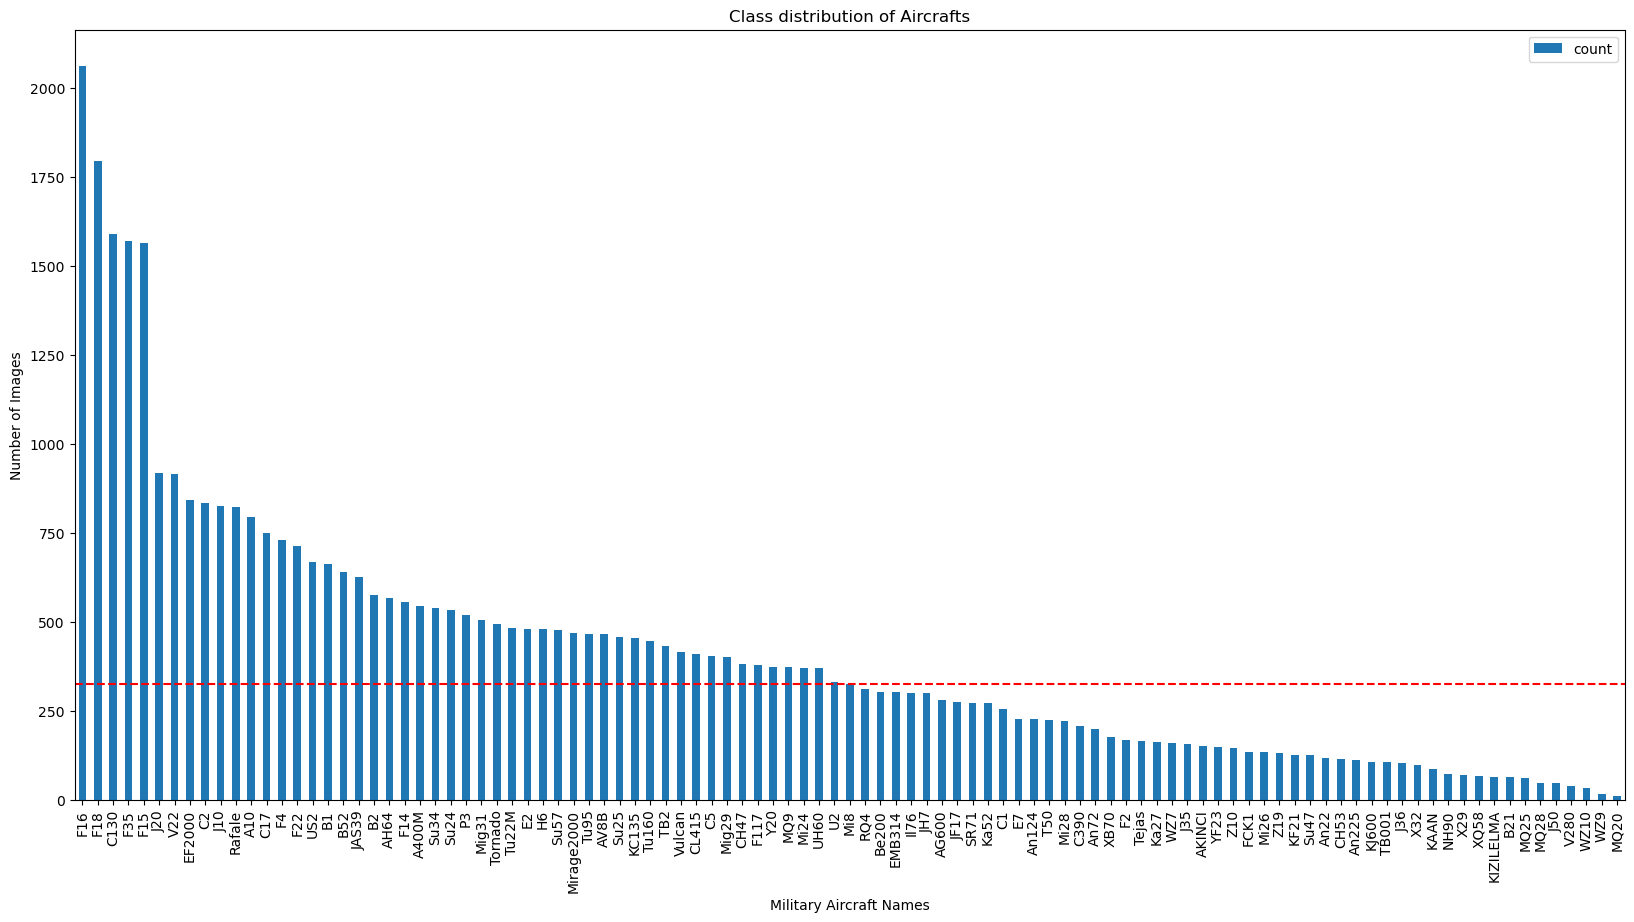

In [28]:
# Visualization of Category distribution of Aircrafts

df.plot.bar(figsize=(20, 10))
plt.title("Class distribution of Aircrafts")
plt.xlabel("Military Aircraft Names")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.axhline(y=np.median(df.values),
           linestyle="--",
           color="red")
plt.show();

# F16 is the dominant class (~2061 images) — the model will naturally lean toward predicting F16 if you don't handle this
# The red median line sits around ~330 images
# Roughly half the classes are below the median — that tail on the right is long
# MQ20 at the far right is nearly invisible (~11 images)

In [29]:
# Top 5 and bottom 5 classes by image count
class_counts = aircraft_labels["label"].value_counts()

top5 = class_counts.head(5)
bottom5 = class_counts.tail(5)

print("Top 5 classes (most images):")
print(top5.to_string())

print("Bottom 5 classes (fewest images):")
print(bottom5.to_string())

Top 5 classes (most images):
label
F16     2061
F18     1796
C130    1590
F35     1569
F15     1564
Bottom 5 classes (fewest images):
label
J50     46
V280    39
WZ10    32
WZ9     15
MQ20    11


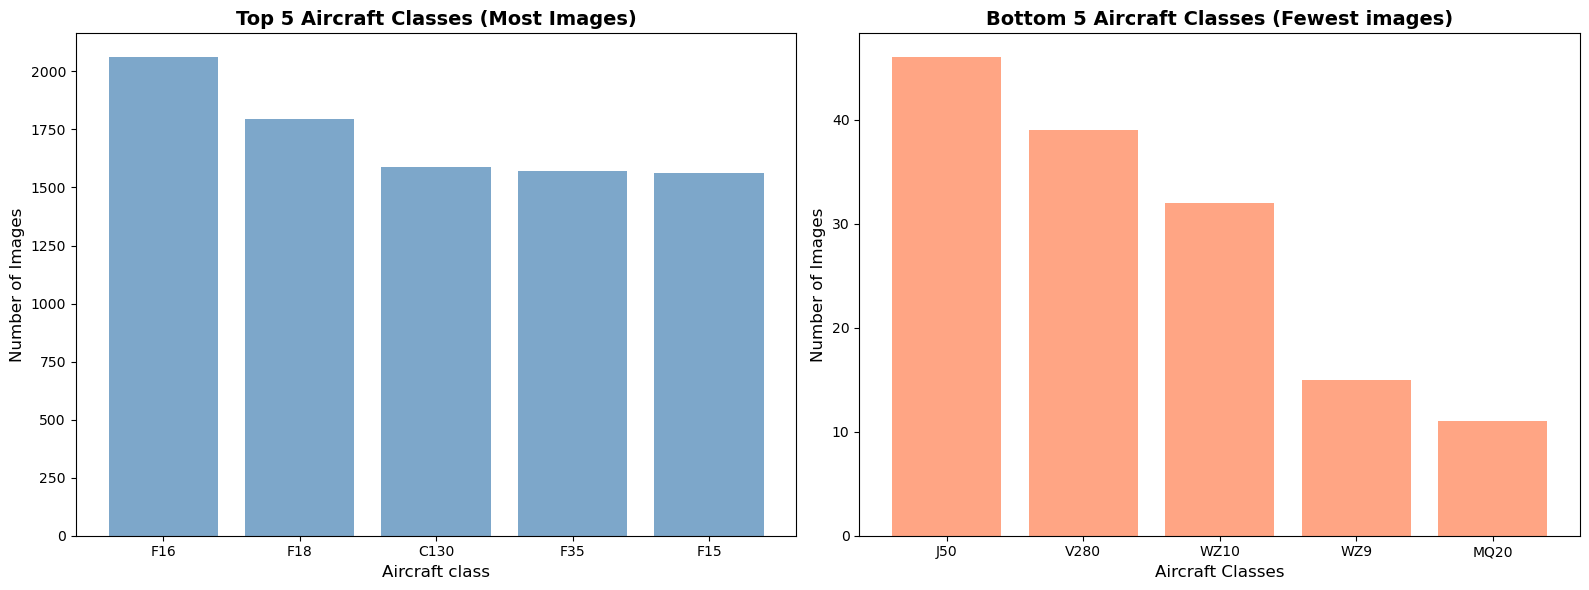

In [30]:
# Visualising the Top 5 and Bottom 5 aircraft classes on the basis of Number of images per class

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6)) # Give me 1 row, 2 columns of subplots.

# Left subplot: Top 5 most common aircraft
ax1.bar(top5.index,
        top5.values,
        color="steelblue",
        alpha=0.7)   # alpha controls transparency (opacity) of a plotted element: 0.0 = fully transparent, 1.0 = fully opaque.
ax1.set_title("Top 5 Aircraft Classes (Most Images)",
              fontsize=14,
              fontweight="bold")
ax1.set_xlabel("Aircraft class",
               fontsize=12)
ax1.set_ylabel("Number of Images",
               fontsize=12)

# Right subplot: Bottom 5 least common aircraft
ax2.bar(bottom5.index,
        bottom5.values,
        color="coral",
        alpha=0.7)
ax2.set_title("Bottom 5 Aircraft Classes (Fewest images)",
              fontsize=14,
              fontweight="bold")
ax2.set_xlabel("Aircraft Classes",
               fontsize=12)
ax2.set_ylabel("Number of Images",
               fontsize=12)

# Cleanup spacing so labels don't overlap
plt.tight_layout()
plt.show();

In [31]:
aircraft_labels.head()

,filepath,label,split
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,train
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,train
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,train
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,train
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,train


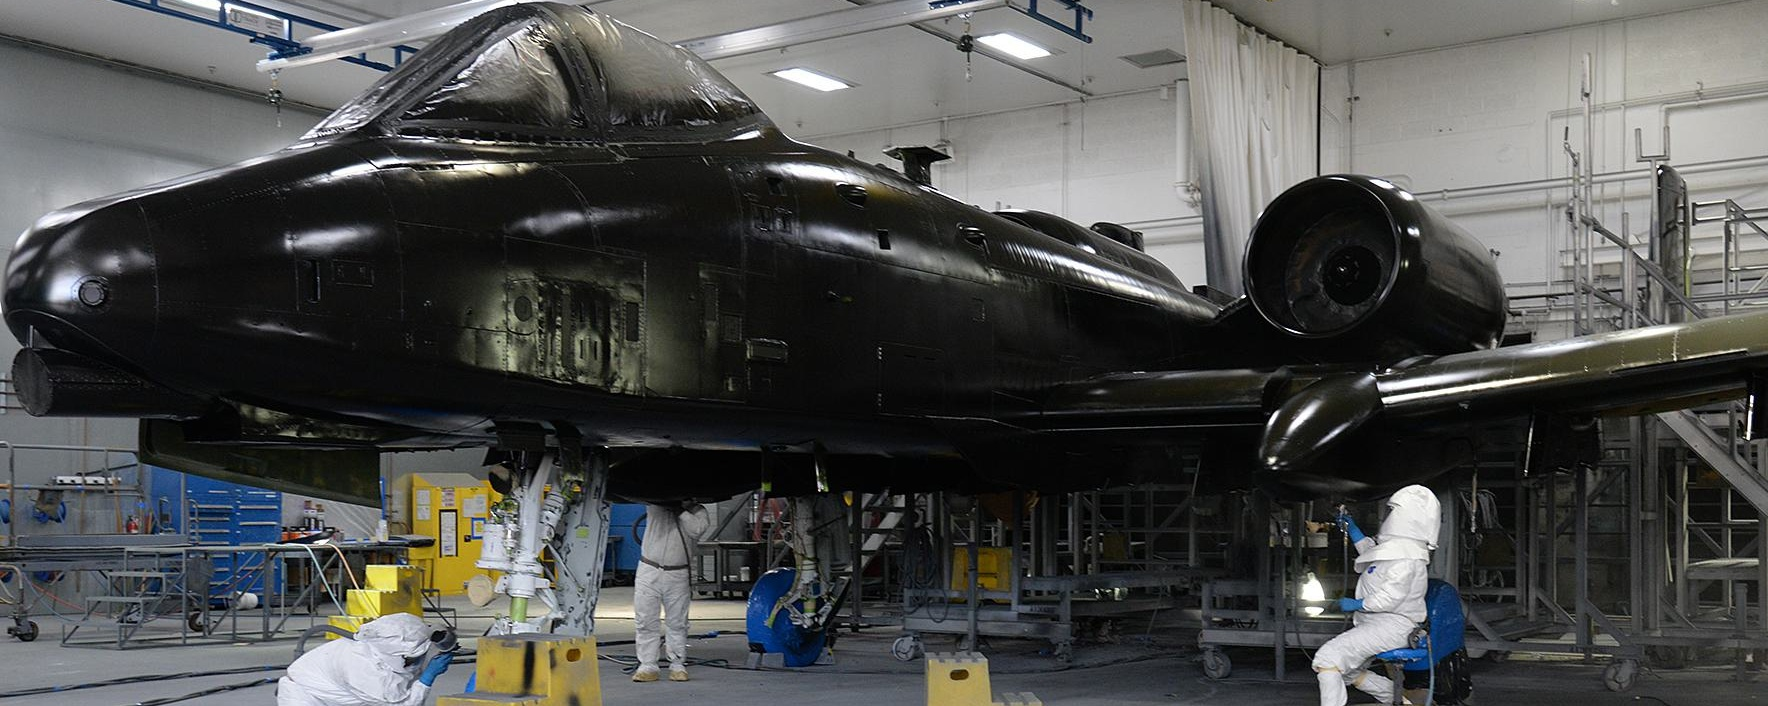

In [32]:
# Let's view an image
from IPython.display import Image
Image(str(aircraft_labels["filepath"][0]))

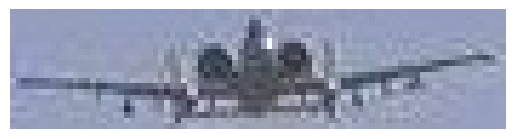

In [33]:
# Another way
# PIL = Python Imaging Library. 
# It loads image files into an object you can
# manipulate (resize, crop, convert color channels etc.) 
# before displaying. Think of it as the "image handler" 
# and matplotlib as the "screen."

from PIL import Image
img = Image.open(aircraft_labels["filepath"][1])
plt.axis("off")
plt.imshow(img);

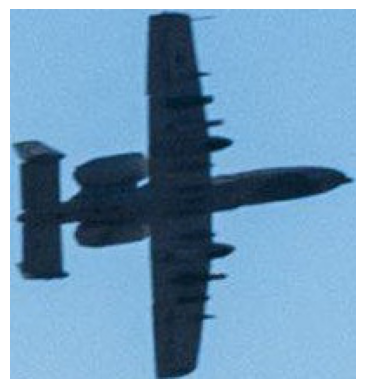

In [34]:
# Another way
img_path = aircraft_labels["filepath"].iloc[2]
img = plt.imread(img_path)
plt.imshow(img)
plt.axis("off")
plt.show();

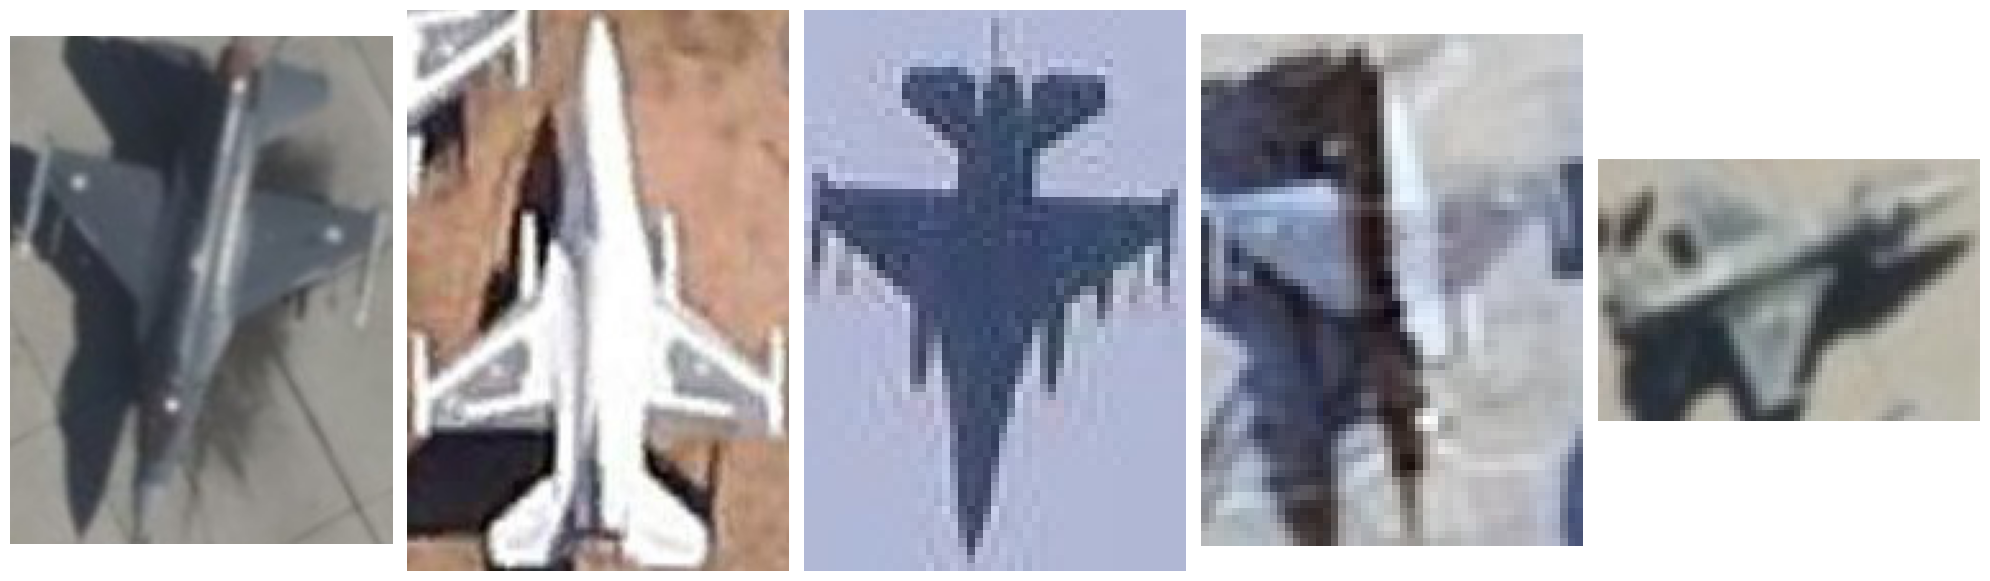

In [35]:
# Showing 5 Random images of F16

# Creating a DataFrame only for F16
f16_df = aircraft_labels[aircraft_labels["label"] == "F16"]
# Taking random 5 paths
random_path_f16 = f16_df["filepath"].sample(n=5, random_state=42).to_list()

# Create 1 row, 5 columns of subplots
fig, axes = plt.subplots(1, 5, figsize=(20, 8))

# Plot image in its own subplot
for ax, path in zip(axes, random_path_f16):
    img = plt.imread(path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()    
plt.show();


# axes[0]  ←→  path_1
# axes[1]  ←→  path_2
# axes[2]  ←→  path_3



In [36]:
# Making function to plot random 5 images of a class

def show_class_images(class_name:str):
    """
    This function takes any class name and shows 5 random images of that Aircraft class
    """
    # Creating a Dataframe for the specific class
    class_df = aircraft_labels[aircraft_labels["label"] == class_name]
    
    # Taking random 5 filepaths of the class as list
    random_image_paths = class_df["filepath"].sample(n=5, random_state=42).to_list()
    
    # Ploting a figure with 1 row and 5 columns
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))  # figsize=(width, height)
    
    # Plot image in its own subplot
    for ax, path in zip(axes, random_image_paths):
        img = plt.imread(path)   # plt.imread(path) reads the image file and returns it as a numpy array of shape (height, width, channels). Channels is usually 3 for RGB.
        ax.imshow(img)
        ax.axis("off")
        ax.set_aspect("auto")   # tells matplotlib to adapts to any image shape
    
    # So that all image look nice and constant
    fig.suptitle(class_name)
    plt.tight_layout()  # It automatically adjusts spacing between subplots so they don't overlap or get cut off — titles, labels, images all stay clean.
    plt.show();

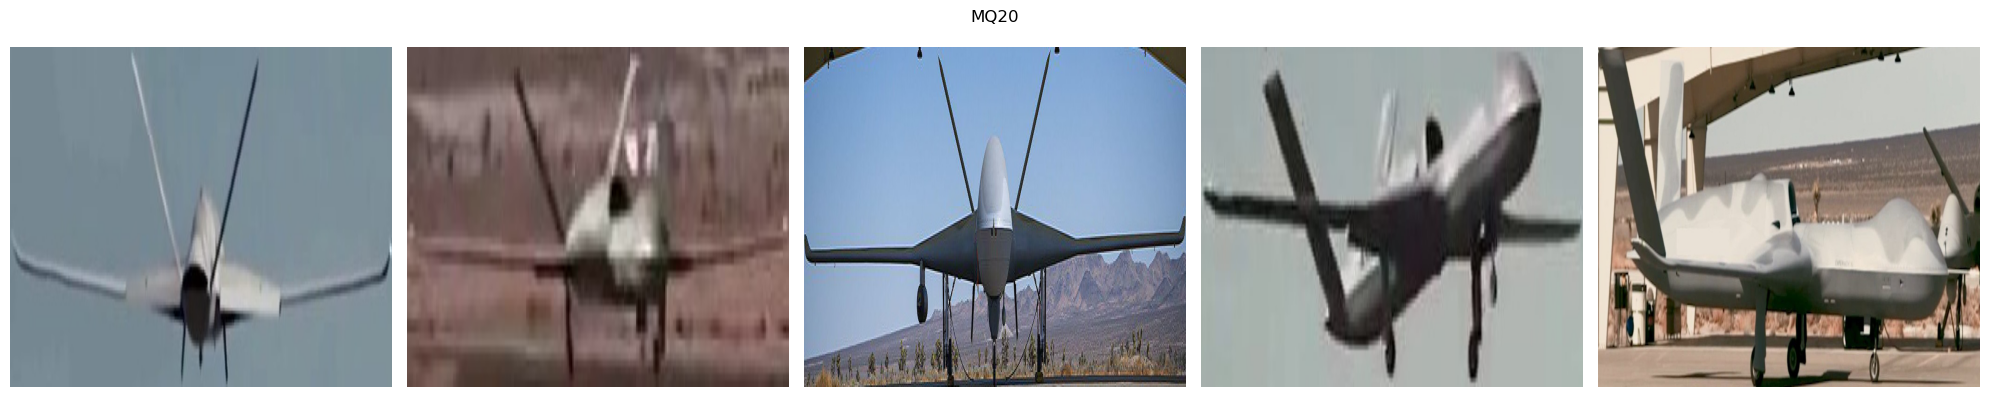

In [37]:
# Show images for aircraft MQ20
show_class_images("MQ20")

(50, 250, 3)


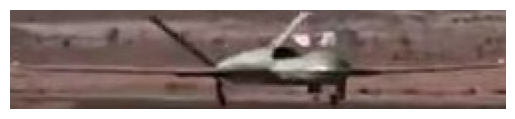

In [38]:
# Checking the actual pixel dimensions for one image Eg. MQ20
mq20_df = aircraft_labels[aircraft_labels["label"] == "MQ20"]

# Taking one image
img = plt.imread(mq20_df["filepath"].iloc[0])  # iloc -> integer index based finder (only the position)

# Dimention of the image
print(img.shape)

# Showing the image
plt.imshow(img)
plt.axis("off")
plt.show();

**(50, 250, 3) means:**

- 50 pixels tall
- 250 pixels wide
- 3 color channels (RGB)

### **Collecting shape of each image in the dataset**

Transfer learning models (like **MobileNetV2** which you'll use) require all images to be the **same fixed size** as input — e.g. `(224, 224, 3)`. So you have to resize everything.

**The question is:** what size should you resize to?

- If your images are mostly 50×250, resizing to 224×224 squashes them badly and loses information
  
- If sizes vary wildly across the dataset, you need to know the range before deciding

This EDA step tells you the reality of your data so you make an informed resize decision not a random one.


**What we are gonna need is:**
- Min height and width
- Max height and width
- Median height and width

In [39]:
# # Collect the shape of every image in the dataset and store the heights and weights seperately

# # Creating a Image path df
# image_path_df = aircraft_labels["filepath"]

# # shape -> (height, width, channels)
# height = []
# width = []

# # Itterating over paths
# for path in image_path_df.values:
#     img = plt.imread(path)  # Converted in NumPy array
#     shape = img.shape
#     height.append(shape[0])
#     width.append(shape[1])
    
# # Create a Shape dataframe
# shape_df = pd.DataFrame({
#     "height" : height,
#     "width" : width,
# })

# shape_df

In [40]:
# # Getting Max, Min and Median values for Height and Width

# # Height
# max_height = np.max(shape_df["height"])
# min_height = np.min(shape_df["height"])
# median_height = np.median(shape_df["height"])

# # Width
# max_width = np.max(shape_df["width"])
# min_width = np.min(shape_df["width"])
# median_width = np.median(shape_df["width"])

# print("Max Height: ", max_height)
# print("Min Height: ", min_height)
# print("Median Height: ", median_height)
# print()
# print("Max Width: ", max_width)
# print("Min Width: ", min_width)
# print("Median Width: ", median_width)

**Looking at these numbers carefully:**

- **Heights** range from `5px` to `4912px`, **median** `174px`
- **Widths** range from `9px` to `8074px`, **median** `364px`
---

### **EDA Insights**

#### **Class Distribution**
- Dataset: 41,441 images across 101 aircraft classes
- Significant class imbalance exists
- **Top 5 classes (most images):** F16 (2061), F18 (1796), C130 (1590), F35 (1569), F15 (1564)
- **Bottom 5 classes (fewest images):** J50 (46), V280 (39), WZ10 (32), WZ9 (15), MQ20 (11)
- Median class size: ~330 images
- Imbalance risk: model may bias toward majority classes (e.g. F16)

#### **Image Size Distribution**
- Heights range from 5px to 4912px — median 174px
- Widths range from 9px to 8074px — median 364px
- Sizes vary wildly across the dataset
- **Resize decision: (224, 224)** — sits above median, standard for transfer learning models like MobileNetV2

#### **Visual Sample Check**
- Verified labels visually using random samples per class
- Images are wide and short in most cases (confirmed via shape check)

In [41]:
# Image shape constants — derived from 41,441 image analysis
MAX_HEIGHT = 4912
MIN_HEIGHT = 5
MEDIAN_HEIGHT = 174

MAX_WIDTH = 8074
MIN_WIDTH = 9
MEDIAN_WIDTH = 364

# Resize target for transfer learning
IMG_SIZE = (224, 224)

### **Constants**

- Image shape analysis was run once across all 41,441 images. Results hardcoded to avoid recomputation.
  
- Resize target set to (224, 224) - standard for **MobileNetV2** transfer learning.
  
- **EfficientNetB4** considered but requires 4-6GB VRAM at 380×380 input - too tight for a 4GB GPU.

---

## **8. Data Pipeline (Image Loading + Preprocessing)**

The model cannot train on a CSV of filepaths. This section builds the pipeline that:
1. Encodes labels into one-hot vectors (101 classes) ✅
2. Loads images from disk using their filepaths ✅
3. Normalizes pixel values from [0, 255] to [0, 1] ✅ 
4. Resizes all images to (224, 224) for MobileNetV2 ✅
5. Batches and shuffles data using tf.data for efficient training ✅

### **Encoding labels (One-Hot Encoding)**

Each label is a string (e.g. "F16"). The model outputs 101 probabilities — one per class.
To compare against that, each label must become a 101-length boolean array.

Approach:
- Get all 101 unique class names (sorted → consistent order) ✅
- For each image's label, compare against every class ✅
- Where it matches → 1, everywhere else → 0 ✅

In [42]:
aircraft_labels["label"]

0        A10
1        A10
2        A10
3        A10
4        A10
        ... 
41436    Z19
41437    Z19
41438    Z19
41439    Z19
41440    Z19
Name: label, Length: 41441, dtype: str

In [43]:
# Getting all the names of the aircrafts
unique_classes = sorted(np.unique(aircraft_labels["label"]))
unique_classes = np.array(unique_classes)
print(unique_classes.shape)
unique_classes

(101,)


array(['A10', 'A400M', 'AG600', 'AH64', 'AKINCI', 'AV8B', 'An124', 'An22',
       'An225', 'An72', 'B1', 'B2', 'B21', 'B52', 'Be200', 'C1', 'C130',
       'C17', 'C2', 'C390', 'C5', 'CH47', 'CH53', 'CL415', 'E2', 'E7',
       'EF2000', 'EMB314', 'F117', 'F14', 'F15', 'F16', 'F18', 'F2',
       'F22', 'F35', 'F4', 'FCK1', 'H6', 'Il76', 'J10', 'J20', 'J35',
       'J36', 'J50', 'JAS39', 'JF17', 'JH7', 'KAAN', 'KC135', 'KF21',
       'KIZILELMA', 'KJ600', 'Ka27', 'Ka52', 'MQ20', 'MQ25', 'MQ28',
       'MQ9', 'Mi24', 'Mi26', 'Mi28', 'Mi8', 'Mig29', 'Mig31',
       'Mirage2000', 'NH90', 'P3', 'RQ4', 'Rafale', 'SR71', 'Su24',
       'Su25', 'Su34', 'Su47', 'Su57', 'T50', 'TB001', 'TB2', 'Tejas',
       'Tornado', 'Tu160', 'Tu22M', 'Tu95', 'U2', 'UH60', 'US2', 'V22',
       'V280', 'Vulcan', 'WZ10', 'WZ7', 'WZ9', 'X29', 'X32', 'XB70',
       'XQ58', 'Y20', 'YF23', 'Z10', 'Z19'], dtype='<U10')

In [44]:
# Generating boolean label for F16
unique_classes == "F16"

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False])

Right now it's **True/False**. We want **1/0**.

In [45]:
# Generating integer label for F16
(unique_classes == "F16").astype(int)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Let's make a function that convert string label into one-hot encoded array

In [46]:
# Function to convert a single label string into a one-hot encoded array

def label_to_encoded_array(label:str):
    """
    Convert the label of the aircraft into one-hot encoded array of length of 101, 
    every value in 101 length array reperesent each aircraft
    1 -> True
    0 -> False
    """
    
    encoded_label = (unique_classes == str(label)).astype(int)
    return encoded_label

In [47]:
# Getting encoded labels for Su57
encoded_su57 = label_to_encoded_array("Su57")
encoded_su57

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Since now we have a function to convert our labels into one-hot encoded array let's apply this on our whole dataset

In [48]:
aircraft_labels

,filepath,label,split
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,train
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,train
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,train
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,train
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,train
...,...,...,...
41436,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41437,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41438,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test
41439,../data/crop/Z19/ffb195452d886cd8cd303777eee8a...,Z19,test


In [49]:
aircraft_labels["encoded_label"] = aircraft_labels["label"].map(label_to_encoded_array)
aircraft_labels.head()

,filepath,label,split,encoded_label
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,train,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,train,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,train,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,train,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,train,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


**Now we have encoded all the labels in to one-hot encoded arrays, which can be understood by our model.**

Now let's load and preprocess our images

### **Loading and Preprocessing Images**

Each image must be:
- Loaded from disk using its filepath
- Decoded into a tensor (RGB)
- Resized to (224, 224) -> MobileNetV2 input requirement
- Normalized from [0, 255] to [0, 1] -> helps the model train faster and more stably

In [50]:
# Method 1
# Open the image
image = plt.imread(aircraft_labels["filepath"][0])
print(image.shape)
print()

# Convert the image into tensor
tensor_image = tf.constant(image)  # Passing numpy array
print(tensor_image.shape)
print(tensor_image.dtype)
print(tensor_image)

(706, 1768, 3)

(706, 1768, 3)
<dtype: 'uint8'>
tf.Tensor(
[[[145 145 147]
  [142 142 144]
  [140 140 142]
  ...
  [123 120 111]
  [125 122 113]
  [126 123 114]]

 [[143 143 145]
  [141 141 143]
  [139 139 141]
  ...
  [126 123 114]
  [125 122 113]
  [125 122 113]]

 [[142 142 144]
  [140 140 142]
  [139 139 141]
  ...
  [127 124 115]
  [126 123 114]
  [126 123 114]]

 ...

 [[143 143 151]
  [143 143 151]
  [144 144 152]
  ...
  [ 59  61  58]
  [ 59  61  58]
  [ 59  61  58]]

 [[145 144 149]
  [144 143 148]
  [143 144 148]
  ...
  [ 56  58  55]
  [ 55  57  54]
  [ 54  56  53]]

 [[145 144 149]
  [144 143 148]
  [142 143 147]
  ...
  [ 54  56  53]
  [ 53  55  52]
  [ 53  55  52]]], shape=(706, 1768, 3), dtype=uint8)


2026-05-11 12:38:07.644082: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-11 12:38:07.937328: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-11 12:38:07.937421: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-11 12:38:07.942231: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-11 12:38:07.942338: I external/local_xla/xla/stream_executor

In [51]:
# Method 2
# Read raw bytes from the disk
raw = tf.io.read_file(aircraft_labels["filepath"][0])

# Decode into image tensor (RGB)
image = tf.image.decode_jpeg(raw, channels=3)

print(image.shape)
print(image.dtype)
print(image)

(706, 1768, 3)
<dtype: 'uint8'>
tf.Tensor(
[[[144 144 144]
  [142 142 142]
  [140 140 140]
  ...
  [123 120 111]
  [125 122 113]
  [126 123 114]]

 [[142 142 142]
  [140 140 140]
  [139 139 139]
  ...
  [125 122 113]
  [125 122 113]
  [124 121 112]]

 [[142 142 142]
  [140 140 140]
  [139 139 139]
  ...
  [126 123 114]
  [126 123 114]
  [126 123 114]]

 ...

 [[146 149 156]
  [146 149 154]
  [147 150 157]
  ...
  [ 58  60  55]
  [ 58  60  55]
  [ 58  60  55]]

 [[144 145 150]
  [143 144 148]
  [142 143 148]
  ...
  [ 55  57  54]
  [ 55  57  54]
  [ 54  56  53]]

 [[143 144 148]
  [142 143 147]
  [141 142 146]
  ...
  [ 53  55  52]
  [ 53  55  52]
  [ 52  54  51]]], shape=(706, 1768, 3), dtype=uint8)


#### **Image Loading**
- `tf.io.read_file(filepath)` -- reads raw bytes from disk, stays inside TF
- `tf.image.decode_jpeg(raw, channels=3)` -- decodes bytes into RGB tensor
- Must use TF-native functions (not `plt.imread`) so the pipeline can run efficiently at scale

**Why not plt.imread + tf.constant?**
- plt.imread is a Python operation -- TF cannot include it in an automated pipeline
- tf.constant just wraps existing memory -- it does not read files
- TF-native reading stays on the assembly line -- faster, parallelizable, pipeline-compatible

In [52]:
# Define the image size
# IMG_SIZE = (224, 224) already defined above

# Create a function to preprocess the image
def process_image(image_path:str, image_size=IMG_SIZE):
    """
    Load and preprocess a single image from disk
    - Reads raw bytes from filepath (the image)
    - Decode into RBG tensor
    - Resizes to (224, 224)
    - Normalize pixel values from [0, 225] to [0, 1]
    
    Args:
    filepath: path to the image file (string)
    Returns:
    Preprocessed image tensor of shape (224, 224, 3)
    """
    
    # Read the image as raw vytes from filepath
    image = tf.io.read_file(image_path)
    
    # Decodes into RGB Tensor (Turn the jpg/jpeg image into numerical Tensor with 3 colour channels (Red, Green, Blue))
    image = tf.image.decode_jpeg(image, channels=3)
    
    # Convert the colour channel values from 0-255 to 0-1 values (Normalization of pixels)
    image = tf.image.convert_image_dtype(image, tf.float32)
    
    # Resize the image to desired shape
    image = tf.image.resize(image, image_size)
    
    return image

#### **Image Preprocessing Function** — `process_image()`
- Takes a single filepath string as input
- `tf.io.read_file()` — reads raw bytes from disk
- `tf.image.decode_jpeg(channels=3)` — decodes into RGB tensor
- `tf.image.convert_image_dtype(tf.float32)` — normalizes pixels from [0, 255] to [0, 1] (must run before resize — resize converts to float32 internally, which breaks normalization)
- `tf.image.resize()` — resizes to (224, 224)
- Returns a single tensor of shape (224, 224, 3)

In [53]:
# Test process_image on a single image
test_image = process_image(aircraft_labels["filepath"][0])
print(test_image.shape)
print(test_image.dtype)
print(test_image)
print()
print(test_image.numpy().min(), test_image.numpy().max())

(224, 224, 3)
<dtype: 'float32'>
tf.Tensor(
[[[0.5468488  0.5468488  0.5468488 ]
  [0.5540751  0.5540751  0.5540751 ]
  [0.54901963 0.54901963 0.5568628 ]
  ...
  [0.45229104 0.44052634 0.40523222]
  [0.48862532 0.4768606  0.44156653]
  [0.4891736  0.4774089  0.44211477]]

 [[0.5346855  0.5346855  0.5346855 ]
  [0.54723394 0.54723394 0.54723394]
  [0.55024517 0.55024517 0.5580883 ]
  ...
  [0.49596494 0.48420024 0.44890612]
  [0.49316156 0.48139682 0.4461027 ]
  [0.4989321  0.4871674  0.45187327]]

 [[0.52858806 0.52858806 0.5256118 ]
  [0.53042156 0.53042156 0.5274454 ]
  [0.54509807 0.54509807 0.5529412 ]
  ...
  [0.5206804  0.5104038  0.47064543]
  [0.5015754  0.4912988  0.45154038]
  [0.5058824  0.49411768 0.46179974]]

 ...

 [[0.42608032 0.44299415 0.46300405]
  [0.5068915  0.5426906  0.5752743 ]
  [0.4980177  0.5254687  0.55684125]
  ...
  [0.2508198  0.25474137 0.23399076]
  [0.26840422 0.27232578 0.24879639]
  [0.24084528 0.2604531  0.23692371]]

 [[0.5016363  0.51340103 0.533

- `process_image()` takes a single filepath and returns a preprocessed tensor
- Order matters: normalize before resize —> resize converts to float32 internally
- Output: shape (224, 224, 3), dtype float32, pixel values in [0, 1]

### **Building the tf.data Pipeline**

`tf.data.Dataset` is a lazy conveyor belt — loads images on demand, one batch at a time.
Never loads all 41,000 images into memory at once. We give GPU image in Batches (as asked by it Eg. 32)

Pipeline steps:
1. Create dataset from filepaths and encoded labels using `from_tensor_slices()`
2. Map `process_image()` over every filepath
3. Shuffle — randomize order so model doesn't memorize sequence
4. Batch — group into chunks of 32 before feeding to model
5. Prefetch — load next batch while model trains on current one

#### **Split Data into Train / Val / Test**

In [54]:
aircraft_labels["split"].value_counts()

split
train         31127
validation     7545
test           2769
Name: count, dtype: int64

In [55]:
train_df = aircraft_labels[aircraft_labels["split"] == "train"].reset_index(drop=True)
val_df = aircraft_labels[aircraft_labels["split"] == "validation"].reset_index(drop=True)
test_df = aircraft_labels[aircraft_labels["split"] == "test"].reset_index(drop=True)
train_df.head()

,filepath,label,split,encoded_label
0,../data/crop/A10/00c09f406d31a0cd9402862fbd26d...,A10,train,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,../data/crop/A10/00d4b7ea93ca1417393007c61c519...,A10,train,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,../data/crop/A10/01169f9ba735dfcb46dab62bc5649...,A10,train,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,../data/crop/A10/016fd73cdece1b76562ec526ba939...,A10,train,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,../data/crop/A10/01ed4d81c5d733cbaa266b6ea7821...,A10,train,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [56]:
len(train_df), len(val_df), len(test_df)

(31127, 7545, 2769)

In [57]:
# Spliting dataframe into X and y

def get_X_and_y(dataframe):
    """
    Takes the DataFrame and split it into X and y labels.
    X --> filepath
    y --> numpy array of encoded label arrays 
    """
    
    X = dataframe["filepath"].values
    y = np.stack(dataframe["encoded_label"].values)
    
    return X, y

In [58]:
# Initialising X and y for training dataset

X_train, y_train = get_X_and_y(train_df)
X_val, y_val = get_X_and_y(val_df)
X_test, y_test = get_X_and_y(test_df)

In [59]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(31127,) (31127, 101)
(7545,) (7545, 101)
(2769,) (2769, 101)


In [60]:
X_train[0], y_train[0]

('../data/crop/A10/00c09f406d31a0cd9402862fbd26d930_0.jpg',
 array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

### **Creating tf.data Batches**

A function that turns X (filepaths) and y (encoded labels) into batched tf.data pipelines.

**Three cases:**
1. **Training data**: shuffle then batch
2. **Validation data**: batch only (no shuffle)
3. **Test data**: no labels, batch only

In [61]:
# Simple function to return the tuple of (Tensor images, Encoded labels)

def image_label_together(image_path, label):
    """
    Take the image path and  associated encoded label as input,
    processes image into tensor and return the tuple (image, label)
    """
    
    image = process_image(image_path)
    return image, label

In [62]:
BATCH_SIZE = 32

def create_data_batches(X, y=None,
                        batch_size=BATCH_SIZE,
                        valid_data=False, test_data=False):
    """
    Create batches of data out of processed image (X) and label (y) pairs.
    Shuffles the data if it's training data but doesn't shuffle validation and test data.
    Also accepts test data as input (with no labels).
    
    Args:
        X: array of filepaths
        y: array of encoded labels (None for test data)
        batch_size: number of images per batch (default 32)
        valid_data: set True for validation data
        test_data: set True for test data (no labels)
    Returns:
        Batched tf.data.Dataset 
    """
    
    # Test data — no labels, just preprocess images and batch
    if test_data:
        print("Creating test data batches...")
        data = tf.data.Dataset.from_tensor_slices(X)  # No labels for test data
        data = data.map(process_image)                 # Load and preprocess each image
        data_batches = data.batch(batch_size)          # Group into batches of 32
        return data_batches
    
    # Validation data — has labels but no shuffling (consistent evaluation each epoch)
    elif valid_data:
        print("Creating validation data batches...")
        data = tf.data.Dataset.from_tensor_slices((X, y))  # Pair filepaths with labels
        data = data.map(image_label_together)               # Load image + keep label as tuple
        data_batches = data.batch(batch_size)               # Group into batches of 32
        return data_batches
    
    # Training data — shuffle first, then map and batch
    else:
        print("Creating training data batches...")
        data = tf.data.Dataset.from_tensor_slices((X, y))  # Pair filepaths with labels
        data = data.shuffle(buffer_size=len(X))             # Shuffle all filepaths before loading (faster than shuffling images)
        data = data.map(image_label_together)               # Load image + keep label as tuple
        data_batches = data.batch(batch_size)               # Group into batches of 32
        return data_batches

In [63]:
# Creating data batches for Training data
train_data = create_data_batches(X_train, y_train)
train_data

Creating training data batches...


<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.int64, name=None))>

**Here:**

- `(None, 224, 224, 3)` → images — `None` means batch size is flexible, 224x224x3 is correct
  
- `(None, 101)` → labels — 101 one-hot values per image
  
- `dtype=tf.float32` → images normalized ✅
  
- `dtype=tf.int64` → labels as integers ✅

In [64]:
# Creating data batches for Validation data
val_data = create_data_batches(X_val, y_val, valid_data=True)
val_data

Creating validation data batches...


<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.int64, name=None))>

In [65]:
# Creating data batches for Testing data
test_data = create_data_batches(X_test, test_data=True)
test_data

Creating test data batches...


<_BatchDataset element_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)>

### **tf.data Pipeline**

**Key concepts:**
- `tf.data.Dataset` is lazy — loads images on demand, never all at once
- `from_tensor_slices((X, y))` pairs filepaths with labels and converts to tensors automatically
- No need for `tf.constant()` — `from_tensor_slices` handles conversion internally

**Pipeline behaviour by split:**
| Split | Labels | Shuffle | 
|---|---|---|
| Training | ✅ | ✅ shuffle before map (faster) |
| Validation | ✅ | ❌ consistent evaluation each epoch |
| Test | ❌ | ❌ inference only |

**Functions built:**
- `image_label_together(image_path, label)` — loads image and returns (image, label) tuple
- `create_data_batches(X, y, batch_size, valid_data, test_data)` — builds batched tf.data pipeline for any split

**Output shapes:**
- Images: `(None, 224, 224, 3)` — float32, normalized [0, 1]
- Labels: `(None, 101)` — int64, one-hot encoded
- Batch size: 32

---

**All components ready for model training:**
- ✅ Labels one-hot encoded (101 classes)
- ✅ Images loaded, resized to (224, 224), normalized to [0, 1]
- ✅ Data split into train / val / test
- ✅ tf.data pipelines built and verified

---

### **Visualizing Data Batches**

Our data is now in batches, however, these can be a little hard to understand/comprehend, let's visualize them.

In [68]:
# Create a function for viewing images in a data batch
def show_25_images(images, labels):
    """Display a plot of 25 images and their labels from a data batch.

    Args:
    - images
    - labels 
    """
    
    # Setup figure
    plt.figure(figsize=(10,10))
    # Loop through 25 (For displaying 25 images)
    for i in range(25):
        # Create a subplot with 5 rows and 5 columns
        ax = plt.subplot(5, 5, i+1)
        # Display the image
        plt.imshow(images[i])
        # Add the image label as the title
        plt.title(unique_classes[labels[i].argmax()])
        # Turn of the grid lines
        plt.axis("off")
        
    plt.tight_layout()
    plt.show();

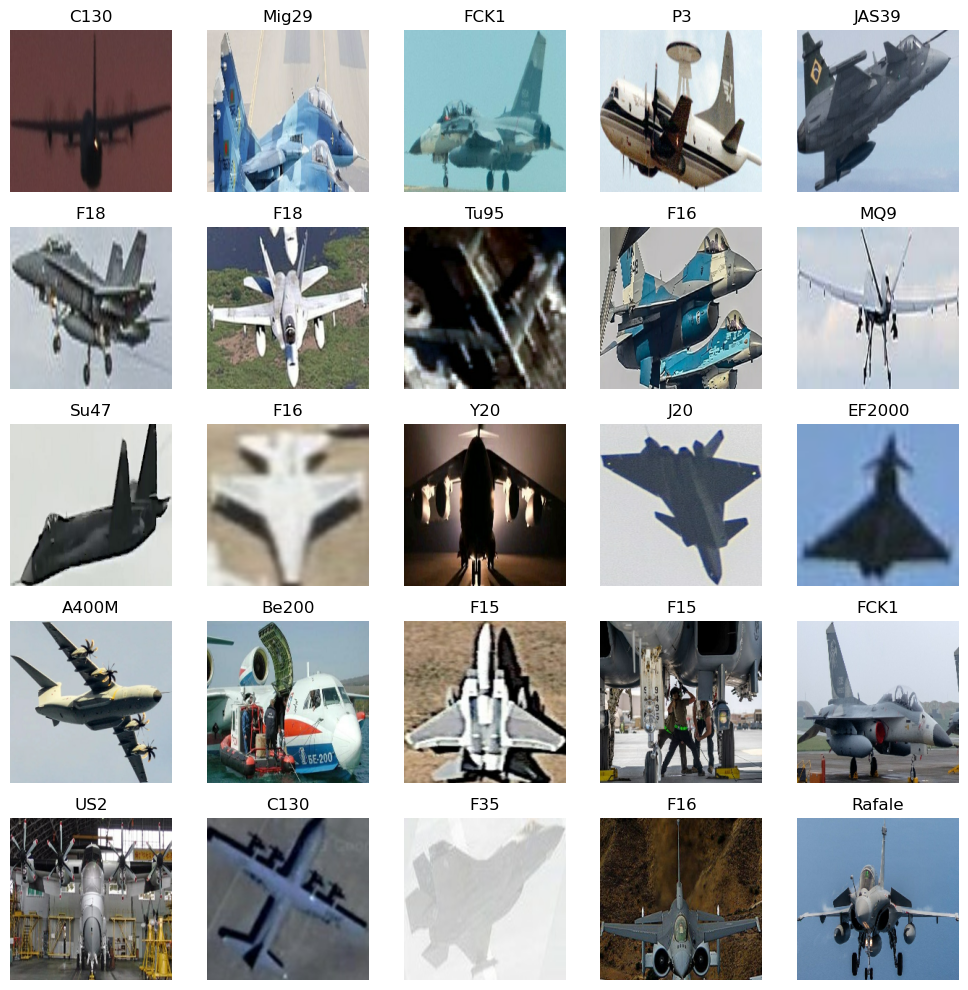

In [71]:
# Now let's visualize the data in training batch
train_images, train_labels = next(train_data.as_numpy_iterator()) # Convert the batch data to an iterator -> grab the next batch from the data that is 32
show_25_images(train_images, train_labels)

## **9. Build and Train Model**

### **Strategy: Transfer Learning**

Rather than training from scratch, we leverage **MobileNetV2** — a CNN pre-trained on 1.2M ImageNet images.

**Workflow:**
- The base model extracts visual features (edges, textures, patterns) — frozen, not retrained
- We attach a custom **101-neuron Dense layer** (one per aircraft class) — this layer alone is trained

| Component | Role | Trainable? |
|-----------|------|-----------|
| MobileNetV2 base | Visual feature extraction | ❌ Frozen |
| Dense output layer (101 units) | Class prediction | ✅ Trained |

---

### **Model Selection: MobileNetV2**

**Why MobileNetV2?**
- **Lightweight:** 3.4M parameters (fits in 4GB VRAM)
- **Fast inference:** Designed for mobile/edge devices
- **Proven:** Pre-trained ImageNet weights
- **Flexible:** Easy to upgrade to EfficientNet if needed

**Configuration:**
- **Variant:** MobileNetV2 (1.4x width multiplier)
- **Input shape:** `(224, 224, 3)` — normalized RGB
- **Output shape:** `(101,)` — one probability per aircraft class

---

### **Model Architecture**

```
Input: (224, 224, 3) ──→ MobileNetV2 (frozen) ──→ Dense(101) ──→ Output: (101,)
       RGB image         Feature extraction        Softmax      Aircraft probability
```

---

### **Upgrade Path (if accuracy insufficient)**

| Model | VRAM | ImageNet Training | Reference |
|-------|------|-------------------|-----------|
| **EfficientNetV2-B0** | ~4GB (local) | 21K classes (ft1k) | [Kaggle Models](https://www.kaggle.com/models/google/efficientnet-v2/tensorFlow2/imagenet21k-ft1k-b0-feature-vector/1) |
| **EfficientNetV2-B3** | ~16GB (Colab) | 21K classes (ft1k) | [Kaggle Models](https://www.kaggle.com/models/google/efficientnet-v2/tensorFlow2/imagenet21k-ft1k-b3-feature-vector/1) |

---
> **Note:** Both use `imagenet21k-ft1k` weights (pre-trained on 21K classes, fine-tuned on 1K) — strongest available for transfer learning.

---

**There are two ways to import a model:**
1. Either do as the kaggle ([eg. mobilenet_v2](https://www.kaggle.com/models/google/mobilenet-v2/tensorFlow2/140-224-feature-vector)) says which is fine (not used here because it caused compatibility issue and refers to legacy/old code.)
2. Use `tf.keras.applications.MODEL_NAME` and you can names at [Keras](https://keras.io/api/applications/) and at [TensorFlow](https://www.tensorflow.org/api_docs/python/tf/keras/applications)

In [ ]:
# Setting image size again before it was like (224, 224)
IMG_SIZE = 224

# Model constants

INPUT_SHAPE = (None, IMG_SIZE, IMG_SIZE, 3) # (Batch size ,height, width, colour channels)
OUTPUT_SHAPE = len(unique_classes) # Number of aircraft classes

In [ ]:
# Create a function that builds a MobileNetV2 transfer learning model

def create_model_mobilenet(input_shape=INPUT_SHAPE,
                           output_shape=OUTPUT_SHAPE):
    """
    Creates a MobileNetV2 transfer learning model for aircraft classification.

    Args:
        input_shape: Shape of input images
                     e.g. (None, 224, 224, 3)

        output_shape: Number of aircraft classes
                      e.g. 101

    Returns:
        A compiled TensorFlow/Keras model
    """

    print("Building MobileNetV2 transfer learning model...")

    # Load pretrained MobileNetV2 base model
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape[1:],   # Remove batch dimension
        include_top=False,             # Remove original ImageNet classifier
        weights="imagenet",            # Load pretrained ImageNet weights
        alpha=1.4                      # Wider MobileNetV2 version
    )

    # Freeze pretrained layers during initial training
    base_model.trainable = False

    # Build transfer learning architecture
    model = tf.keras.Sequential([

        # Feature extraction backbone
        base_model,

        # Convert feature maps into feature vector
        tf.keras.layers.GlobalAveragePooling2D(),

        # Final aircraft classification layer
        tf.keras.layers.Dense(
            units=output_shape,
            activation="softmax"
        )
    ])

    # Build model with full input shape
    model.build(input_shape=input_shape)

    # Configure training setup
    model.compile(

        # Multi-class classification loss function
        loss=tf.keras.losses.CategoricalCrossentropy(),

        # Optimizer updates model weights
        optimizer=tf.keras.optimizers.Adam(),

        metrics=[

            # Exact prediction accuracy
            "accuracy",

            # Checks if correct class exists in top 5 predictions
            tf.keras.metrics.TopKCategoricalAccuracy(
                k=5,
                name="top_5_accuracy"
            )
        ] 
    )

    return model

In [75]:
# Create MobileNetV2 model
mobilenet_model = create_model_mobilenet()

# View model architechture
mobilenet_model.summary()

Building MobileNetV2 transfer learning model...
17831080/17831080 ━━━━━━━━━━━━━━━━━━━━ 362s 20us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.40_224            │ (None, 7, 7, 1792)     │     4,363,712 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 101)            │       181,093 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,544,805 (17.34 MB)

 Trainable params: 181,093 (707.39 KB)

 Non-trainable params: 4,363,712 (16.65 MB)

### **Understanding The Model Summary**

The pretrained MobileNetV2 model converts a `(224 × 224 × 3)` aircraft image into deep feature maps of shape `(7 × 7 × 1792)`.

- `7 × 7` → compressed version of the image
- `1792` → learned visual features like edges, textures, shapes, wings, engines, etc.

`GlobalAveragePooling2D()` converts these feature maps into a `1792-length` feature vector by averaging each feature channel.

The final `Dense(101, softmax)` layer acts as the aircraft classifier and predicts probabilities for all 101 aircraft classes.

### Parameter Understanding

- **Trainable Params** → only the custom classifier layer is being trained
- **Non-Trainable Params** → pretrained ImageNet knowledge remains frozen

This confirms that transfer learning is working correctly.


### **Model Data Flow**

```text
Input Image
(224 × 224 × 3)
        │
        ▼
MobileNetV2 CNN Backbone
Feature Extraction
        │
        ▼
Deep Feature Maps
(7 × 7 × 1792)
        │
        ▼
GlobalAveragePooling2D
Compress Feature Maps
        │
        ▼
Feature Vector
(1792)
        │
        ▼
Dense Layer + Softmax
Aircraft Classification
        │
        ▼
Output Probabilities
(101 Aircraft Classes)
```

### **Creating Callbacks**

Callbacks automate important tasks during training.

Used callbacks:
- **ModelCheckpoint** → saves best model
- **EarlyStopping** → stops bad training early
- **ReduceLROnPlateau** → lowers learning rate when learning slows
- **TensorBoard** → tracks training metrics

These improve:
- training stability
- monitoring
- model management

In [76]:
# Load Tensorboard notebook extention
%load_ext tensorboard

In [81]:
import datetime
import os

# Create a function to build a Tensorboard callback
def create_tensorboard_callback():
    # Create a log dictionary for storing Tensorboard logs
    logdir = os.path.join(str(LOG_DIR), datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
    os.makedirs(logdir, exist_ok=True)
    return tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [ ]:
# Creating all the callbacks for the model

# Folder to save the best trained model
os.makedirs(MODEL_DIR, exist_ok=True)

# Function to create all training callbacks
def create_callbacks():
    return [
        
        # TensorBoard callback - Saves training logs for visualization
        create_tensorboard_callback(),
        
        # EarlyStopping callback - Stops training if validation loss stops improving
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",          # Metric to monitor
            patience=3,                  # Wait 3 epochs before stopping
            restore_best_weights=True    # Restore best model weights
        ),
        
        # ReduceLROnPlateau callback - Lowers learning rate when training gets stuck 
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",   # Metric to monitor
            factor=0.2,           # Reduce LR by 80%
            patience=3,           # Wait 3 epochs before reducing LR
            min_lr=1e-6           # Minimum learning rate
        ),
        
        # ModelCheckpoint callback - Saves the best model during training
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(
                MODEL_DIR,
                f"mobilenetv2_best_model_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.keras"
            ),
            monitor="val_loss",   # Save based on validation loss
            save_best_only=True   # Save only the best model
        )
    ]